# 05 · Walk-Forward Validation & Final Analysis

A single 80/20 split answers "fit the last 20 %". A public-health user needs
"**re-forecast every week with only what was known then**". This notebook re-evaluates
the improved model with an **expanding-window walk-forward**:

```
train ≤ T0            → predict [T0+1 .. T0+7]
train ≤ T0+7          → predict [T0+8 .. T0+14]
train ≤ T0+14         → predict ...            (retrain every 4 folds)
```

* initial train = 60 days, **forecast horizon = 7 days**, weekly step.
* **identical fold dates for LSTM and XGBoost**, 3-city and all-regions, so the
  comparison stays fair.
* every metric is computed on **truly out-of-sample** weeks only.

Same `RUN_TRAINING` switch as notebook 04 (default `False` → load committed results).
Full code: `scripts/{XGBoost,LSTM}_{all_regions,full_period_by_city}_walk_forward.ipynb`.

In [1]:
# --- repo bootstrap: make every path in this notebook repo-relative ---
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "raw").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "data" / "raw").exists(), "launch this notebook from inside the repo"
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

RUN_TRAINING = False
SEED = 0
import time, random
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from IPython.display import Image, display
random.seed(SEED); np.random.seed(SEED)

PROJECT_ROOT = /home/bcrlab/igguest/porat_naama


## 5.1 · Walk-forward schedule & loop (XGBoost, all regions) — *training code*

In [2]:
RAW_PATH = Path("data/raw/geographic-sum-per-day-ver_00859.csv")
OUT_DIR = Path("data/processed/walk_forward/xgboost_all_regions_walk_forward")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MIN_TESTS_ADAPTIVE = 30
MAX_ADAPTIVE_WINDOW_DAYS = 14
FEATURES = ["infection_rate_lag1", "infection_rate_rolling3", "cases_daily", "tests_daily", "hosp_daily"]

INITIAL_TRAIN_DAYS = 60
HORIZON_DAYS = 7
RETRAIN_EVERY_N_FOLDS = 4
MIN_TRAIN_ROWS_PER_AREA = 1     # XGBoost pools rows directly; any valid row can contribute
MIN_TEST_ROWS_FOR_AREA_METRIC = 30  # for the per-region AGGREGATED table at the end

XGB_PARAMS = dict(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=8,
)

EXAMPLE_TOWNS = {3000: "Jerusalem", 5000: "Tel Aviv", 4000: "Haifa"}

In [3]:
# Full walk-forward: feature engineering (backward-looking only) + fold schedule + loop.
# Verbatim from scripts/XGBoost_all_regions_walk_forward.ipynb (cells 5, 7, 9).
if RUN_TRAINING:
    t_start = time.time()
    usecols = ["town_code", "agas_code", "town", "date",
               "accumulated_cases", "accumulated_diagnostic_tests", "accumulated_hospitalized"]
    raw = pd.read_csv(RAW_PATH, usecols=usecols, encoding="utf-8-sig")
    raw = raw.replace("<15", 0)
    for c in ["accumulated_cases", "accumulated_diagnostic_tests", "accumulated_hospitalized"]:
        raw[c] = pd.to_numeric(raw[c], errors="coerce").fillna(0)
    raw["town_code"] = pd.to_numeric(raw["town_code"], errors="coerce").astype(int)
    raw["agas_code"] = pd.to_numeric(raw["agas_code"], errors="coerce").fillna(0).astype(int)
    raw["date"] = pd.to_datetime(raw["date"])
    
    df = raw[raw["agas_code"] != 0].copy()
    df["City_agas_code"] = df["town_code"].astype(str) + "_" + df["agas_code"].astype(str)
    df = df.sort_values(["City_agas_code", "date"]).reset_index(drop=True)
    print(f"Raw rows: {len(df):,}  |  regions: {df['City_agas_code'].nunique():,}  |  "
          f"date range {df['date'].min().date()} - {df['date'].max().date()}")
    
    g = df.groupby("City_agas_code")
    df["cases_daily"] = g["accumulated_cases"].diff().clip(lower=0)
    df["tests_daily"] = g["accumulated_diagnostic_tests"].diff().clip(lower=0)
    df["hosp_daily"] = g["accumulated_hospitalized"].diff().clip(lower=0)
    
    df["infection_rate"] = np.nan
    g = df.groupby("City_agas_code", sort=False)
    for lag in range(1, MAX_ADAPTIVE_WINDOW_DAYS + 1):
        prev_cases = g["accumulated_cases"].shift(lag)
        prev_tests = g["accumulated_diagnostic_tests"].shift(lag)
        prev_date = g["date"].shift(lag)
        cases_in_window = df["accumulated_cases"] - prev_cases
        tests_in_window = df["accumulated_diagnostic_tests"] - prev_tests
        actual_window_days = (df["date"] - prev_date).dt.days
        not_assigned = df["infection_rate"].isna()
        valid = (not_assigned & (tests_in_window >= MIN_TESTS_ADAPTIVE)
                 & (cases_in_window >= 0) & (cases_in_window <= tests_in_window)
                 & (actual_window_days == lag))
        df.loc[valid, "infection_rate"] = (cases_in_window / tests_in_window)[valid]
    
    df["infection_rate_lag1"] = df.groupby("City_agas_code")["infection_rate"].shift(1)
    # FIX vs. build_xgboost_all_regions.ipynb: shift(1) first, so rolling3 never includes the current day
    # (the original `.rolling(3)` alone is inclusive of "today" and leaks the target -- see intro markdown).
    df["infection_rate_rolling3"] = (
        df.groupby("City_agas_code")["infection_rate"].shift(1)
        .groupby(df["City_agas_code"]).rolling(window=3).mean().reset_index(level=0, drop=True)
    )
    
    n_before = len(df)
    df = df.dropna(subset=FEATURES + ["infection_rate"]).reset_index(drop=True)
    print(f"Dropped {n_before - len(df):,} / {n_before:,} rows with a still-NaN feature/target")
    print(f"Feature engineering done in {time.time() - t_start:.1f}s")

    MIN_DATE = df["date"].min()
    MAX_DATE = df["date"].max()
    
    def build_fold_schedule(min_date, max_date, initial_days, horizon_days, retrain_every):
        folds = []
        cutoff = min_date + pd.Timedelta(days=initial_days - 1)
        active_cutoff = cutoff
        fold_id = 0
        retrain_id = -1
        while True:
            test_start = cutoff + pd.Timedelta(days=1)
            if test_start > max_date:
                break
            test_end = min(test_start + pd.Timedelta(days=horizon_days - 1), max_date)
            is_retrain = (fold_id % retrain_every == 0)
            if is_retrain:
                retrain_id += 1
                active_cutoff = cutoff
            folds.append({
                "fold_id": fold_id, "retrain_id": retrain_id, "is_retrain_fold": is_retrain,
                "train_cutoff": active_cutoff, "test_start": test_start, "test_end": test_end,
            })
            fold_id += 1
            cutoff = test_end
        return folds
    
    FOLDS = build_fold_schedule(MIN_DATE, MAX_DATE, INITIAL_TRAIN_DAYS, HORIZON_DAYS, RETRAIN_EVERY_N_FOLDS)
    n_retrains = FOLDS[-1]["retrain_id"] + 1
    print(f"{len(FOLDS)} scored weekly folds, {n_retrains} retrain events")
    print("first fold:", FOLDS[0])
    print("last fold: ", FOLDS[-1])

    all_predictions = []
    fold_metrics = []
    active_model = None
    t_wf = time.time()
    
    for fold in FOLDS:
        train_mask = df["date"] <= fold["train_cutoff"]
        test_mask = (df["date"] >= fold["test_start"]) & (df["date"] <= fold["test_end"])
    
        if fold["is_retrain_fold"]:
            train_df = df[train_mask]
            active_model = XGBRegressor(**XGB_PARAMS)
            active_model.fit(train_df[FEATURES].values, train_df["infection_rate"].values)
    
        test_df = df[test_mask]
        if len(test_df) == 0:
            continue
        y_pred = active_model.predict(test_df[FEATURES].values)
        y_true = test_df["infection_rate"].values
    
        pred_rows = pd.DataFrame({
            "model": "XGBoost", "scope": "all_regions",
            "City_agas_code": test_df["City_agas_code"].values,
            "town_code": test_df["town_code"].values,
            "date": test_df["date"].values,
            "fold_id": fold["fold_id"], "retrain_id": fold["retrain_id"],
            "train_start": MIN_DATE, "train_end": fold["train_cutoff"],
            "forecast_start": fold["test_start"], "forecast_end": fold["test_end"],
            "y_true": y_true, "y_pred": y_pred,
        })
        pred_rows["residual"] = pred_rows["y_pred"] - pred_rows["y_true"]
        all_predictions.append(pred_rows)
    
        fold_metrics.append({
            "fold_id": fold["fold_id"], "retrain_id": fold["retrain_id"],
            "train_end": fold["train_cutoff"], "forecast_start": fold["test_start"], "forecast_end": fold["test_end"],
            "n": len(test_df),
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
            "r2": r2_score(y_true, y_pred) if len(test_df) >= 2 else np.nan,
        })
    
    predictions_df = pd.concat(all_predictions, ignore_index=True)
    fold_metrics_df = pd.DataFrame(fold_metrics)
    print(f"Walk-forward loop done in {(time.time() - t_wf):.1f}s")
    print(f"Total predictions: {len(predictions_df):,}  across {len(fold_metrics_df)} folds")
    print(fold_metrics_df.head())
    predictions_df.to_csv(OUT_DIR / 'xgboost_all_regions_wf_predictions.csv', index=False)
    fold_metrics_df.to_csv(OUT_DIR / 'xgboost_all_regions_wf_fold_metrics.csv', index=False)
else:
    fold_metrics_df = pd.read_csv('data/processed/walk_forward/xgboost_all_regions_walk_forward/xgboost_all_regions_wf_fold_metrics.csv', parse_dates=['forecast_start'])
    print('loaded committed fold metrics:', fold_metrics_df.shape)

loaded committed fold metrics: (158, 9)


## 5.2 · Result — accuracy over the whole pandemic

  model       scope  n_folds  n_retrains  initial_train_days  horizon_days  retrain_every_n_folds  n_predictions      mae    rmse      r2
XGBoost all_regions      158          40                  60             7                      4        1325217 0.013316 0.02478 0.94598


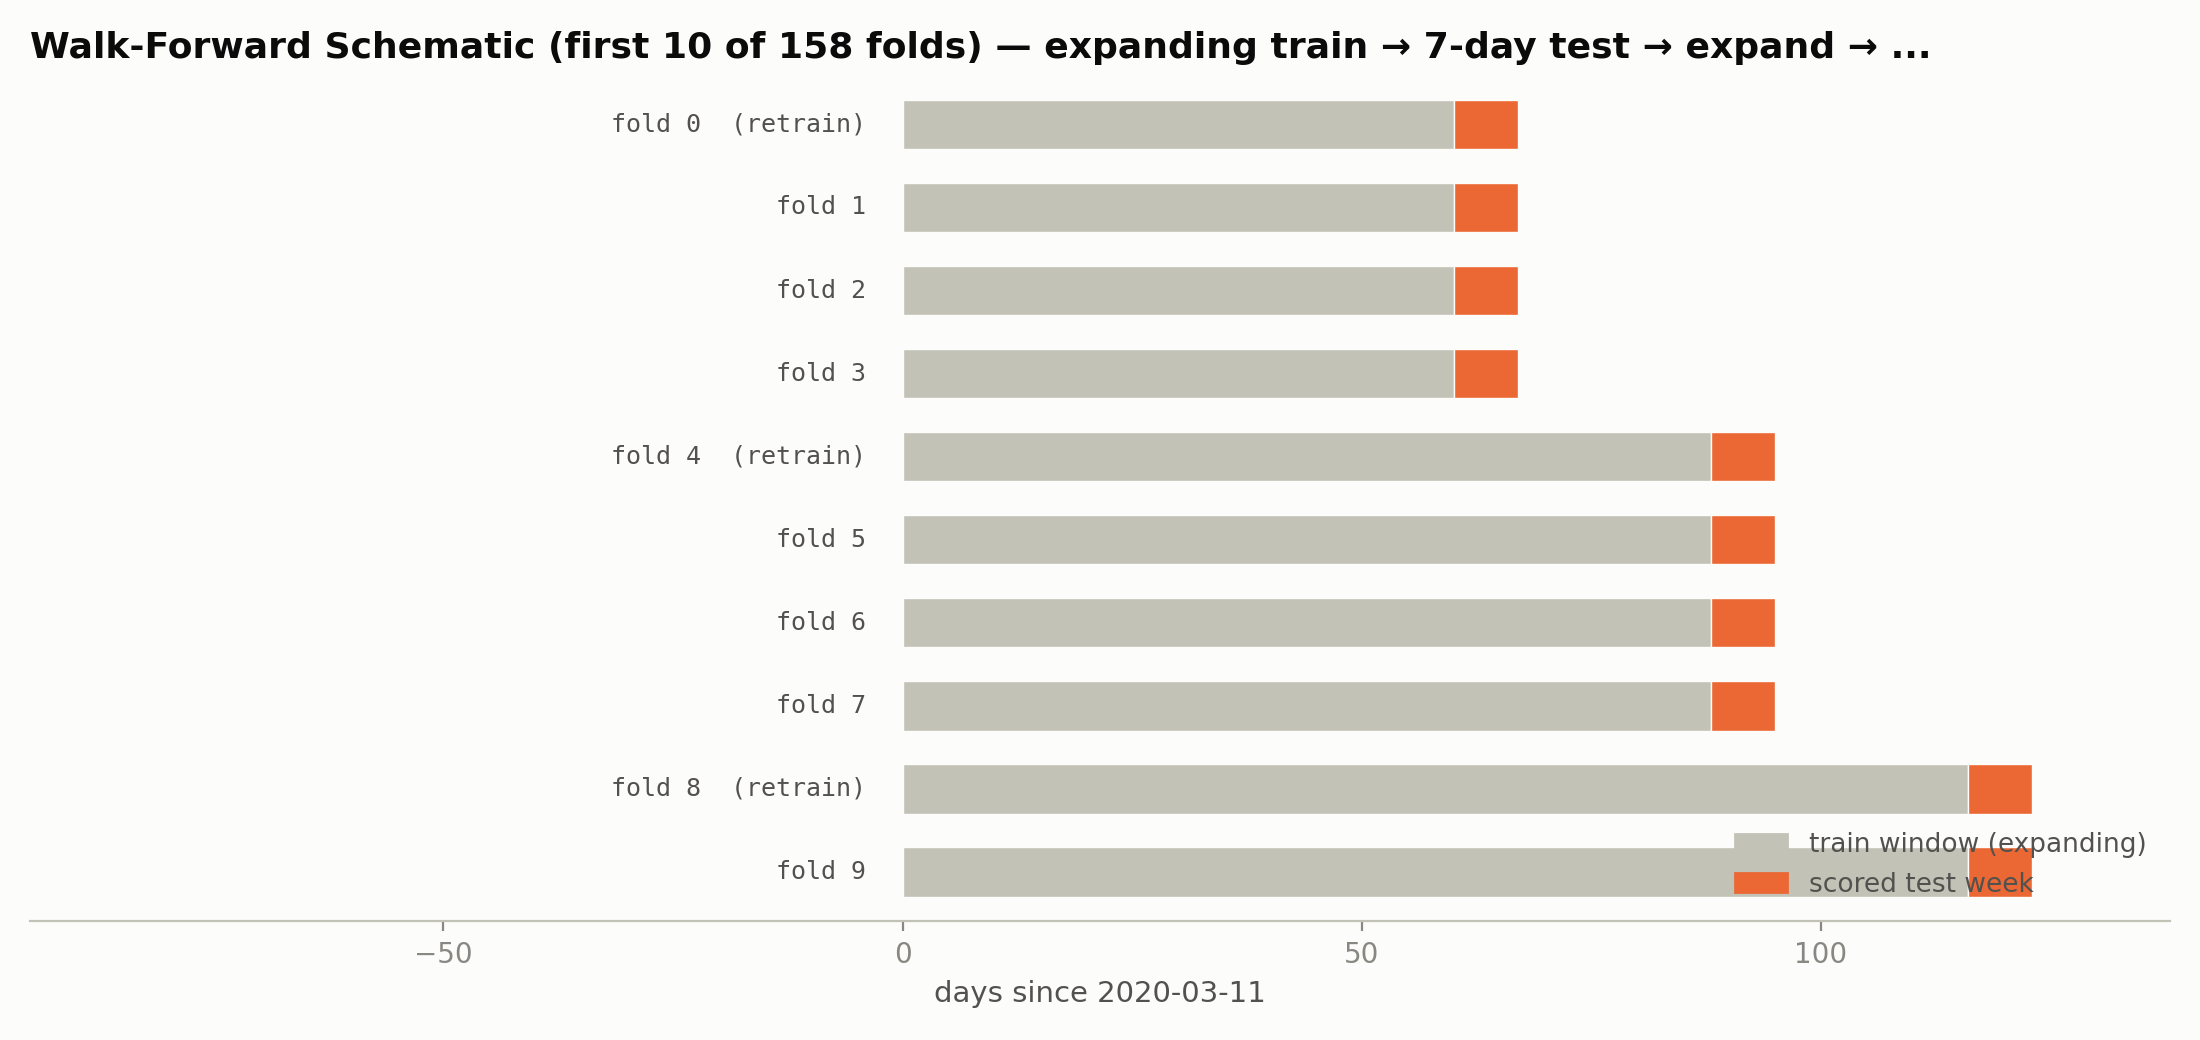

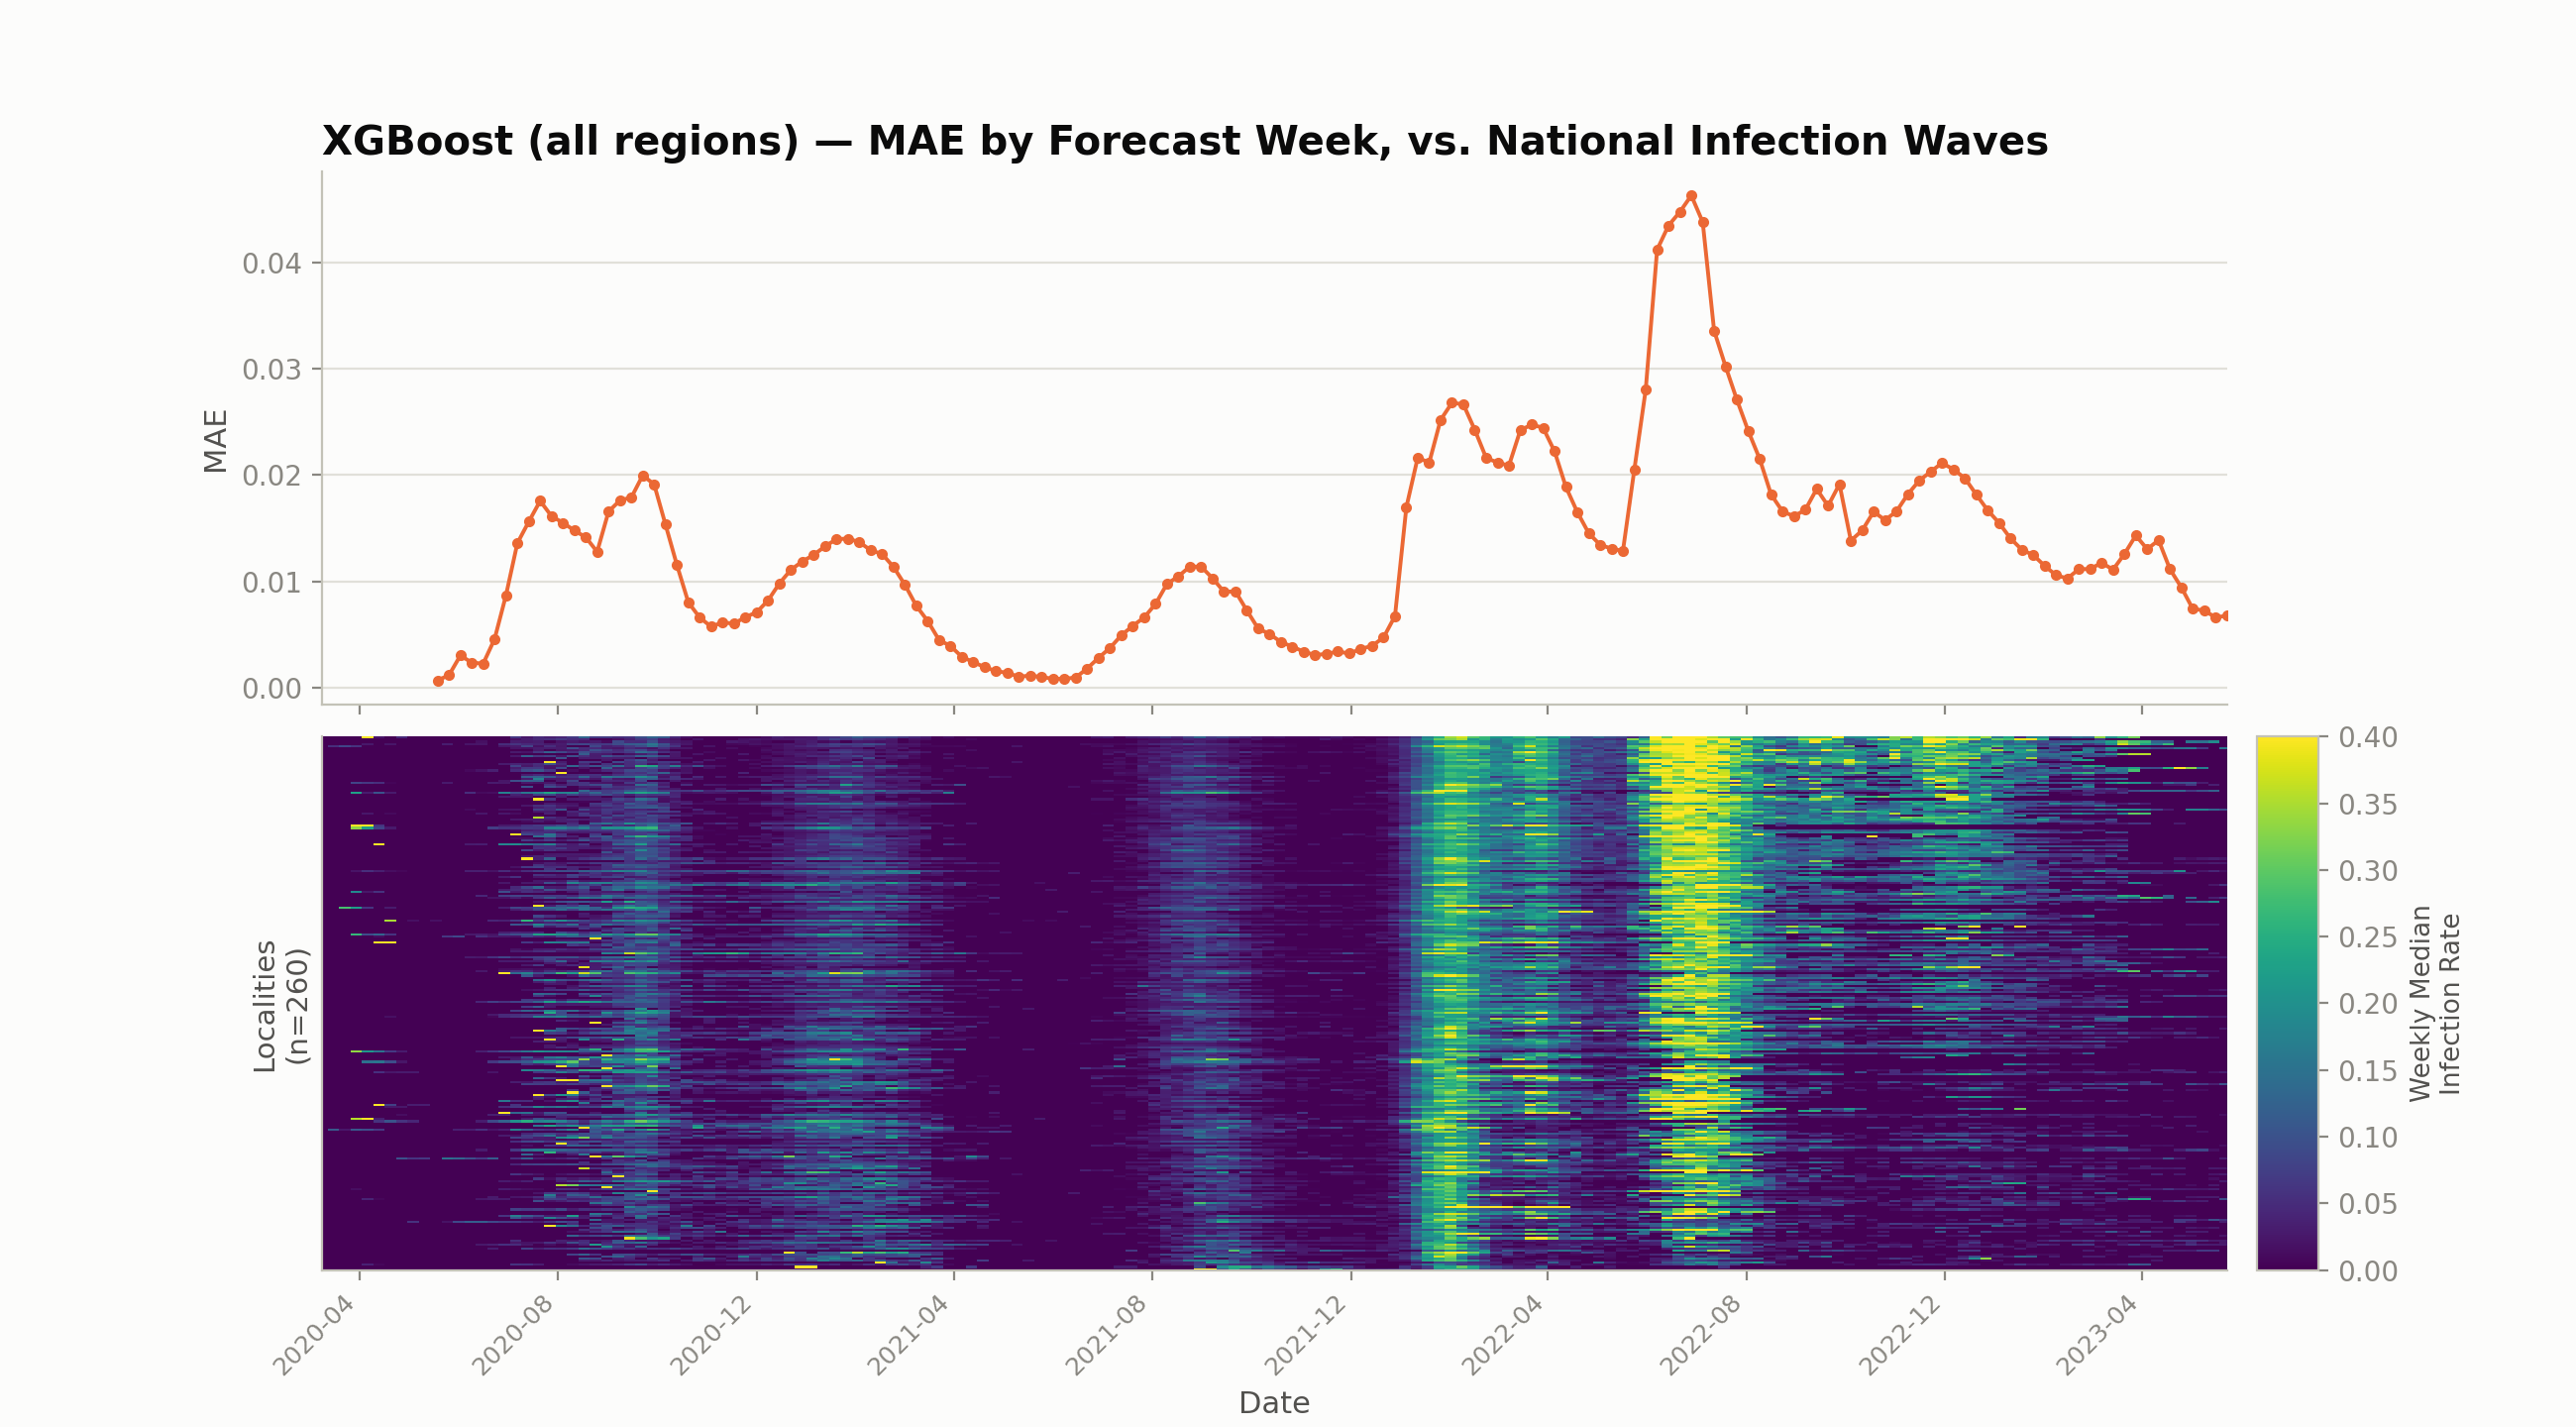

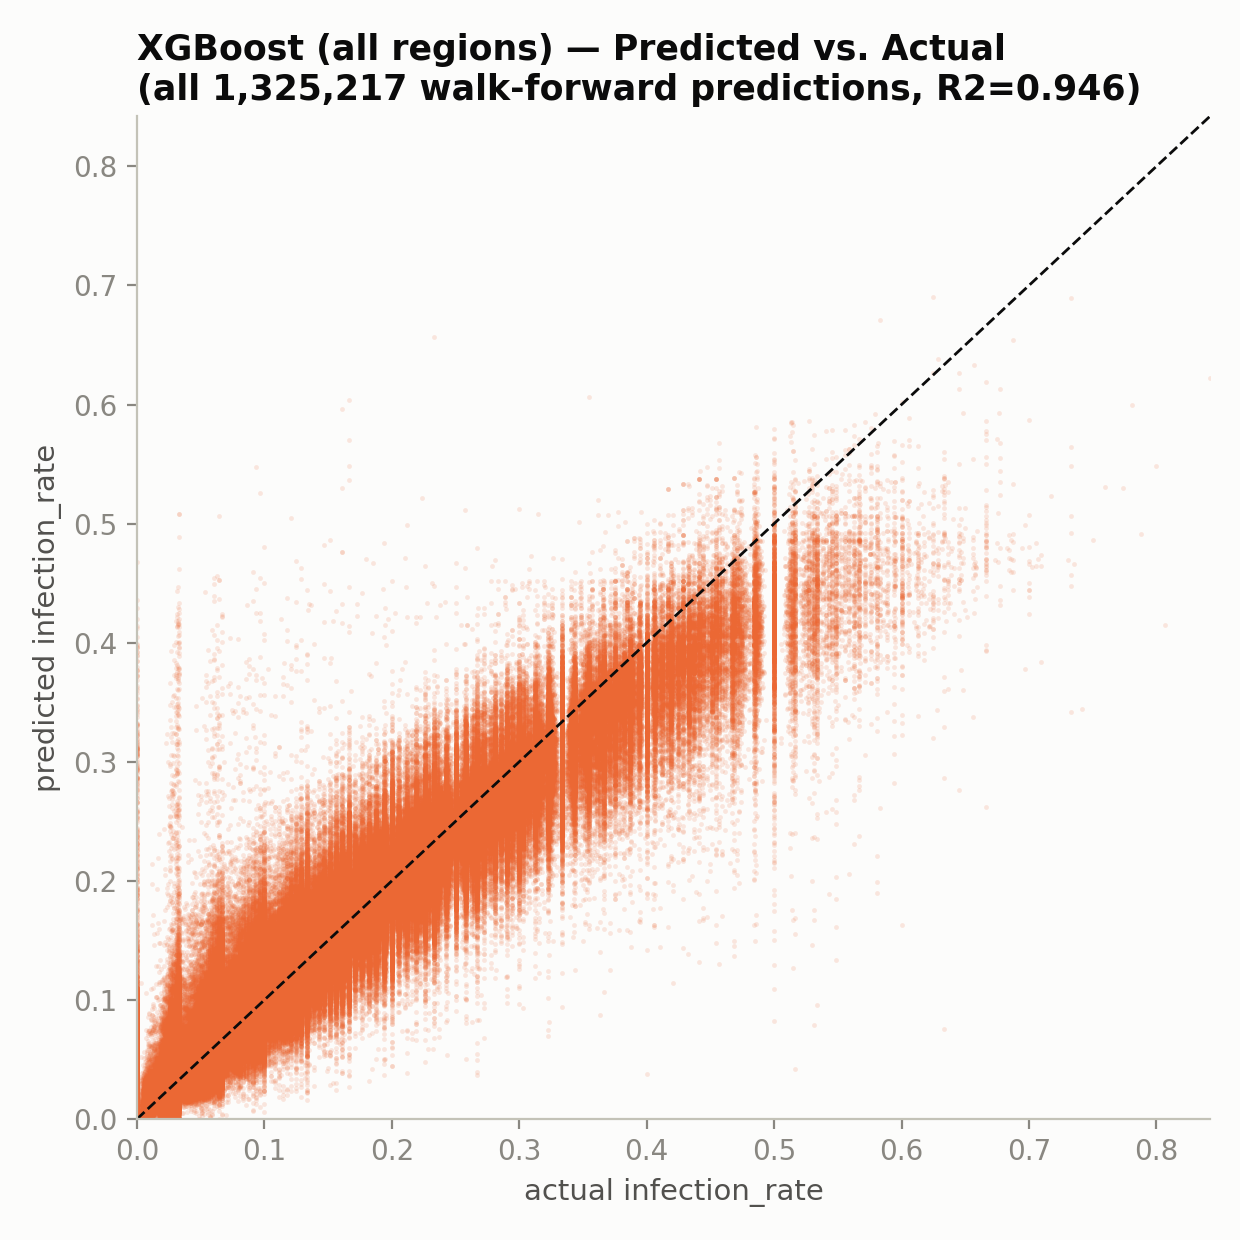

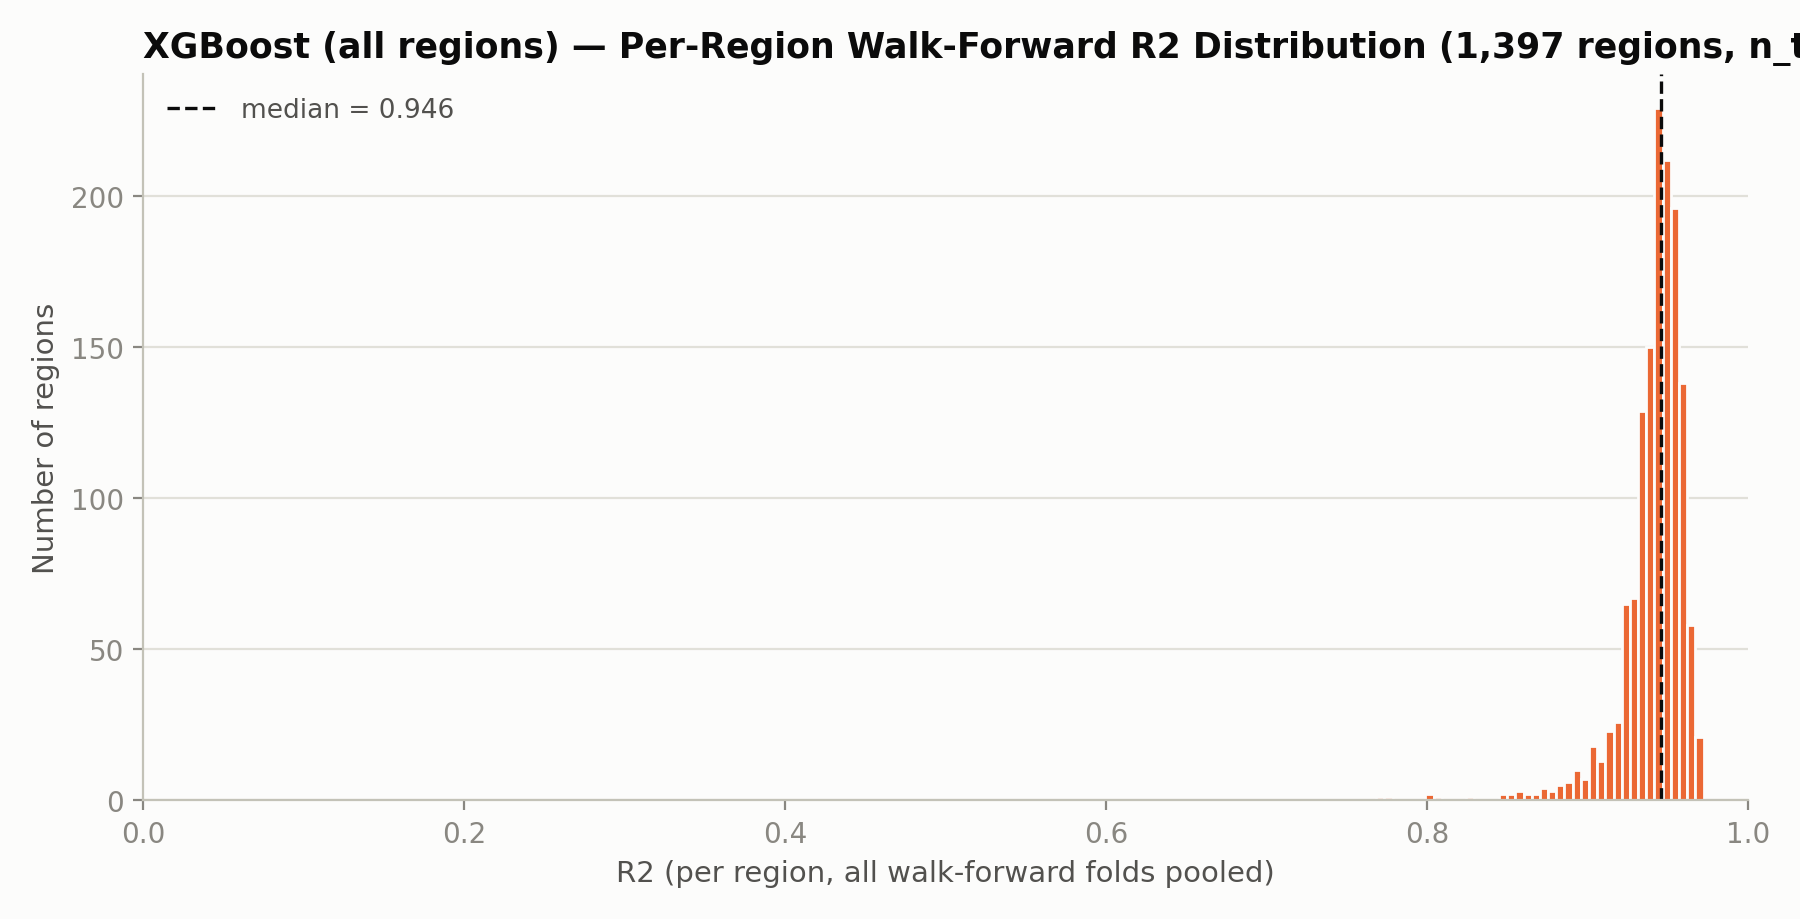

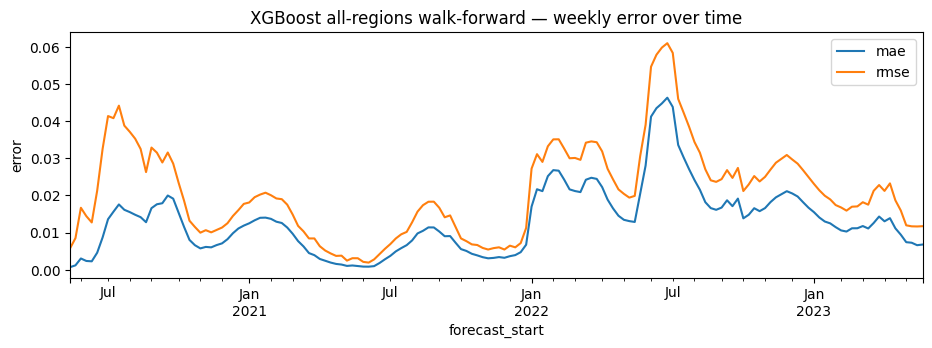

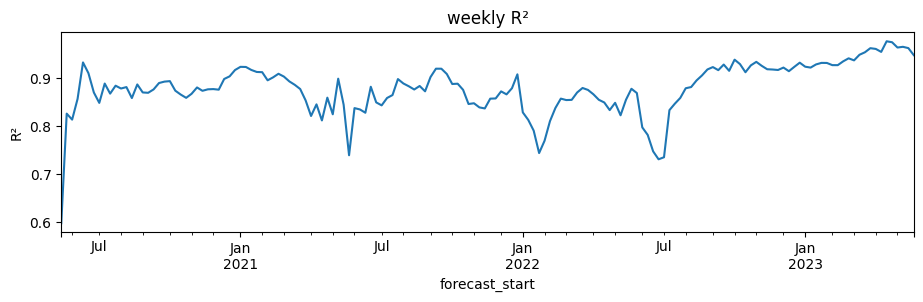

In [4]:
overall = pd.read_csv("data/processed/walk_forward/xgboost_all_regions_walk_forward/xgboost_all_regions_wf_overall_results.csv")
print(overall.to_string(index=False))

ax = fold_metrics_df.plot(x="forecast_start", y=["mae", "rmse"], figsize=(11, 3.2))
ax.set_title("XGBoost all-regions walk-forward — weekly error over time"); ax.set_ylabel("error")
fold_metrics_df.plot(x="forecast_start", y="r2", figsize=(11, 2.6), legend=False,
                     title="weekly R²", ylabel="R²")
for f in ["wf_00_schematic.png", "wf_01_xgb_allregions_mae_vs_waves.png",
          "wf_03_xgb_allregions_scatter.png", "wf_04_xgb_allregions_per_region_r2.png"]:
    display(Image(filename=f"final_submission/figures/05_walk_forward/{f}"))

**What it shows.** Over **1,325,217** genuinely prospective weekly predictions the
shared XGBoost keeps **R² ≈ 0.946 / MAE ≈ 0.013**. But the weekly-error curve and the
wave-overlay figure make the failure mode explicit: **absolute error rises on every
wave up-swing** — the model lags at turning points and slightly under-predicts peaks
(scatter). Between waves it is very accurate. For a surge-warning use-case, that is
exactly the wrong place to be weakest, and is the key limitation to state plainly.

## 5.3 · The other three walk-forward runs (committed results)

                  run      mae     rmse       r2
   XGBoost · 3 cities 0.013332 0.023901 0.945332
      LSTM · 3 cities 0.035186 0.064412 0.599741
XGBoost · all regions 0.013316 0.024780 0.945980
   LSTM · all regions 0.024154 0.077097 0.192539


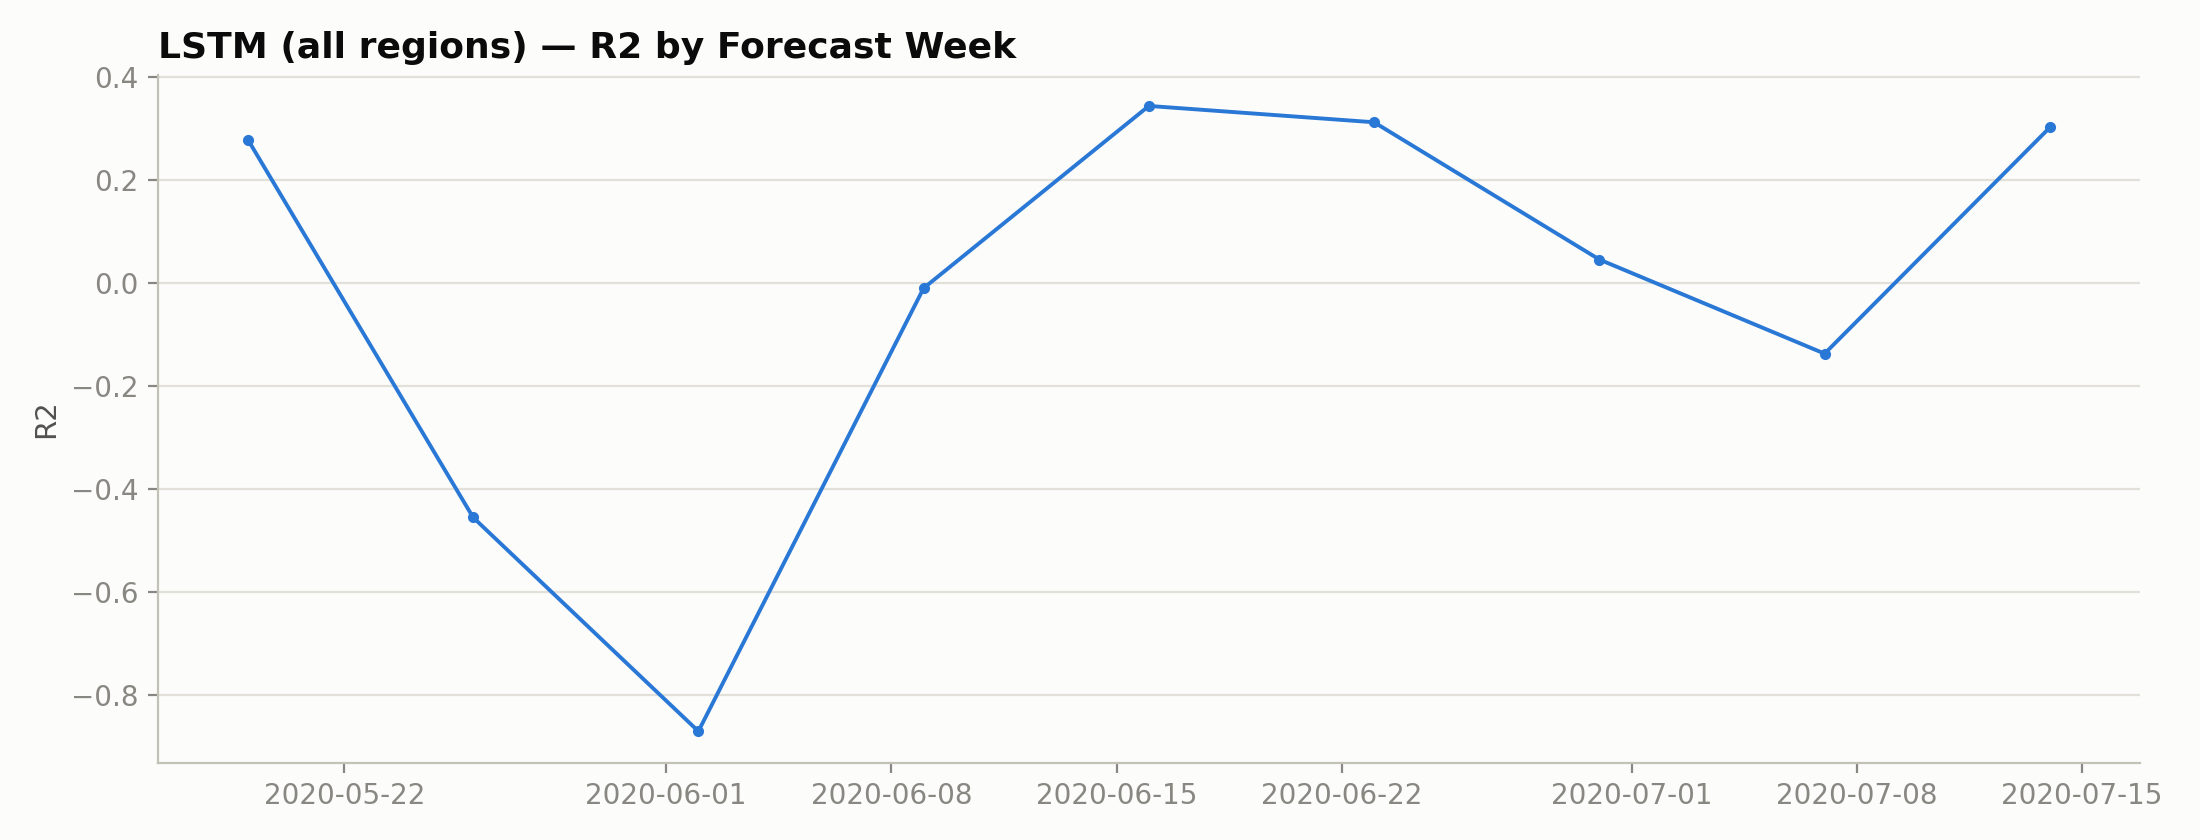

In [5]:
rows = []
for name, path in {
    "XGBoost · 3 cities":  "xgboost_full_period_by_city_walk_forward/xgboost_full_period_by_city_wf_overall_results.csv",
    "LSTM · 3 cities":     "lstm_full_period_by_city_walk_forward/lstm_full_period_by_city_wf_overall_results.csv",
    "XGBoost · all regions": "xgboost_all_regions_walk_forward/xgboost_all_regions_wf_overall_results.csv",
    "LSTM · all regions":  "lstm_all_regions_walk_forward/lstm_all_regions_wf_overall_results.csv",
}.items():
    df = pd.read_csv(f"data/processed/walk_forward/{path}")
    num = df.select_dtypes("number").iloc[0]
    rows.append({"run": name, **{k: num[k] for k in ("mae", "rmse", "r2") if k in num}})
print(pd.DataFrame(rows).to_string(index=False))
display(Image(filename="final_submission/figures/05_walk_forward/wf_06_lstm_allregions_r2_over_time.png"))

**XGBoost is stable under the stricter test** — all-regions walk-forward R² ≈ 0.95,
essentially unchanged from its static-split score. **The LSTM degrades sharply** once
evaluation is fully prospective (3-city R² ≈ 0.6, all-regions R² far lower), i.e. its
static-split score was partly flattered by the single fixed split. This widens, not
narrows, the gap between the two families and is itself a finding: for this problem a
gradient-boosted model on lag features is both more accurate *and* more robust than a
lightly-tuned LSTM.

## 5.4 · Secondary target — hospitalisation-rate walk-forward
Does the approach transfer to a sparser, harder target? Same XGBoost walk-forward, target = daily hospitalisation rate (`scripts/XGBoost_all_regions_hospitalization_walk_forward.ipynb`).

  model       scope               target  n_folds  n_retrains  initial_train_days  horizon_days  retrain_every_n_folds  n_predictions      mae     rmse       r2
XGBoost all_regions hospitalization_rate      158          40                  60             7                      4         620811 0.005985 0.025679 0.898934


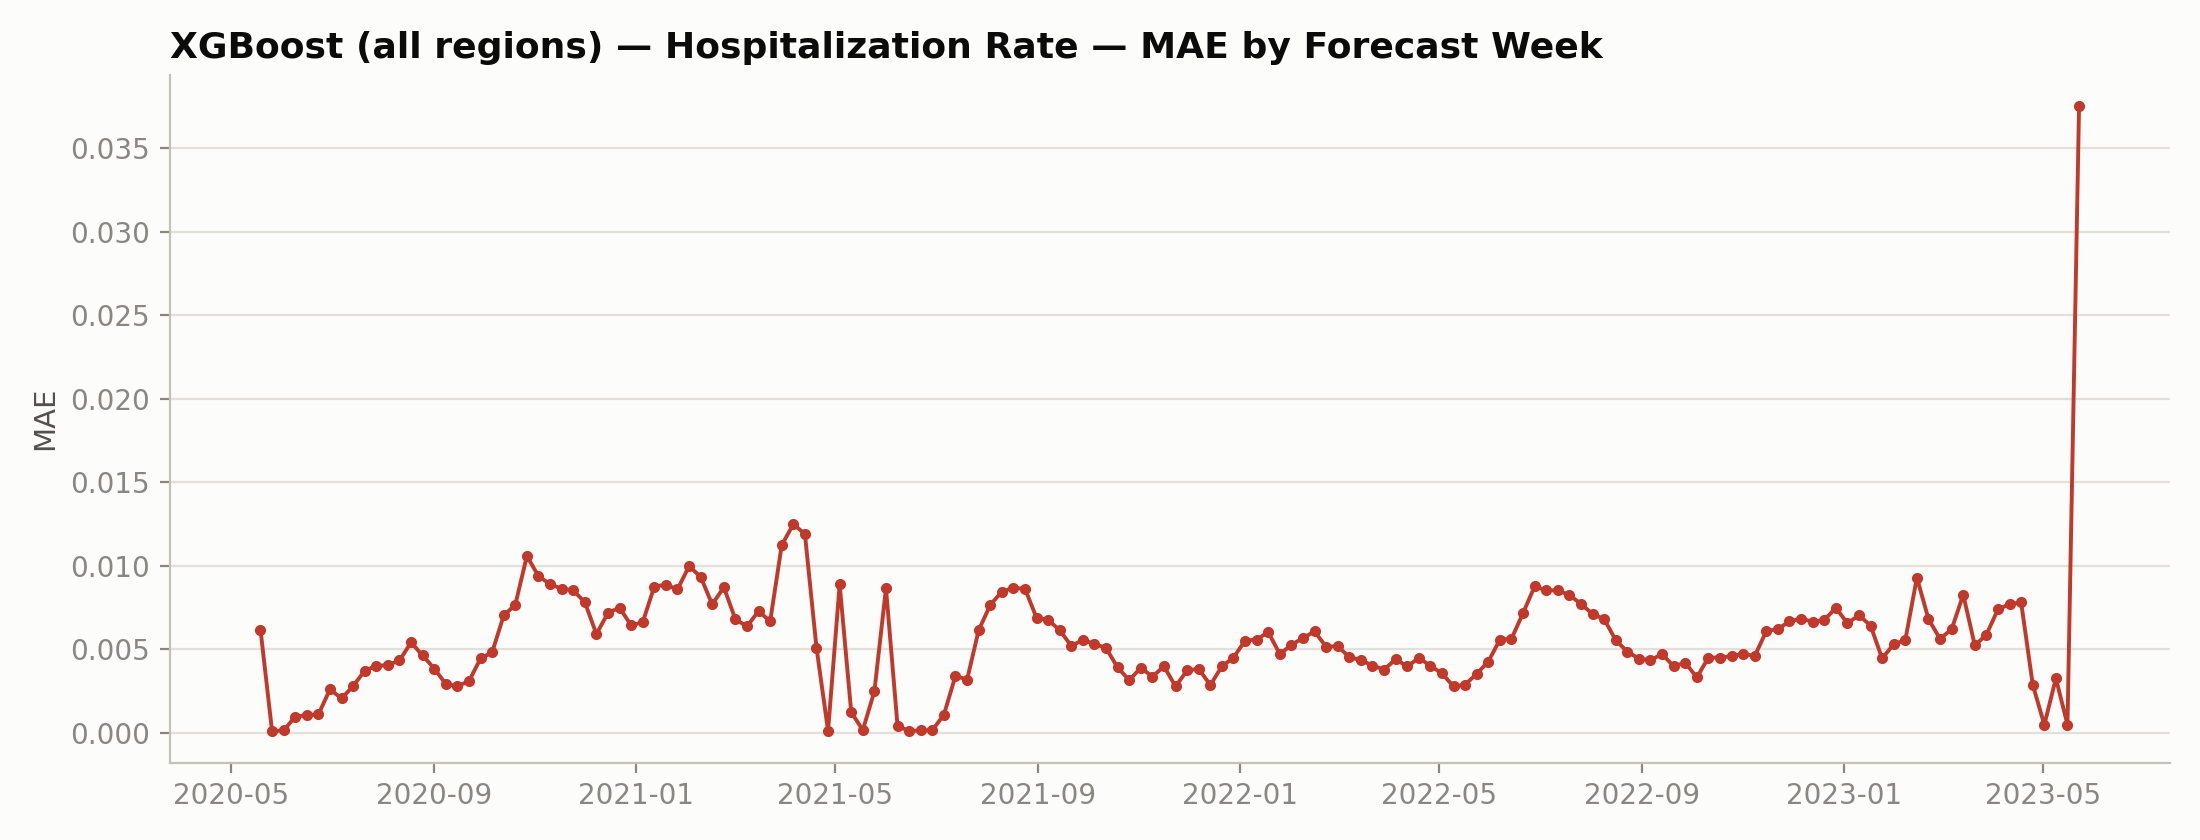

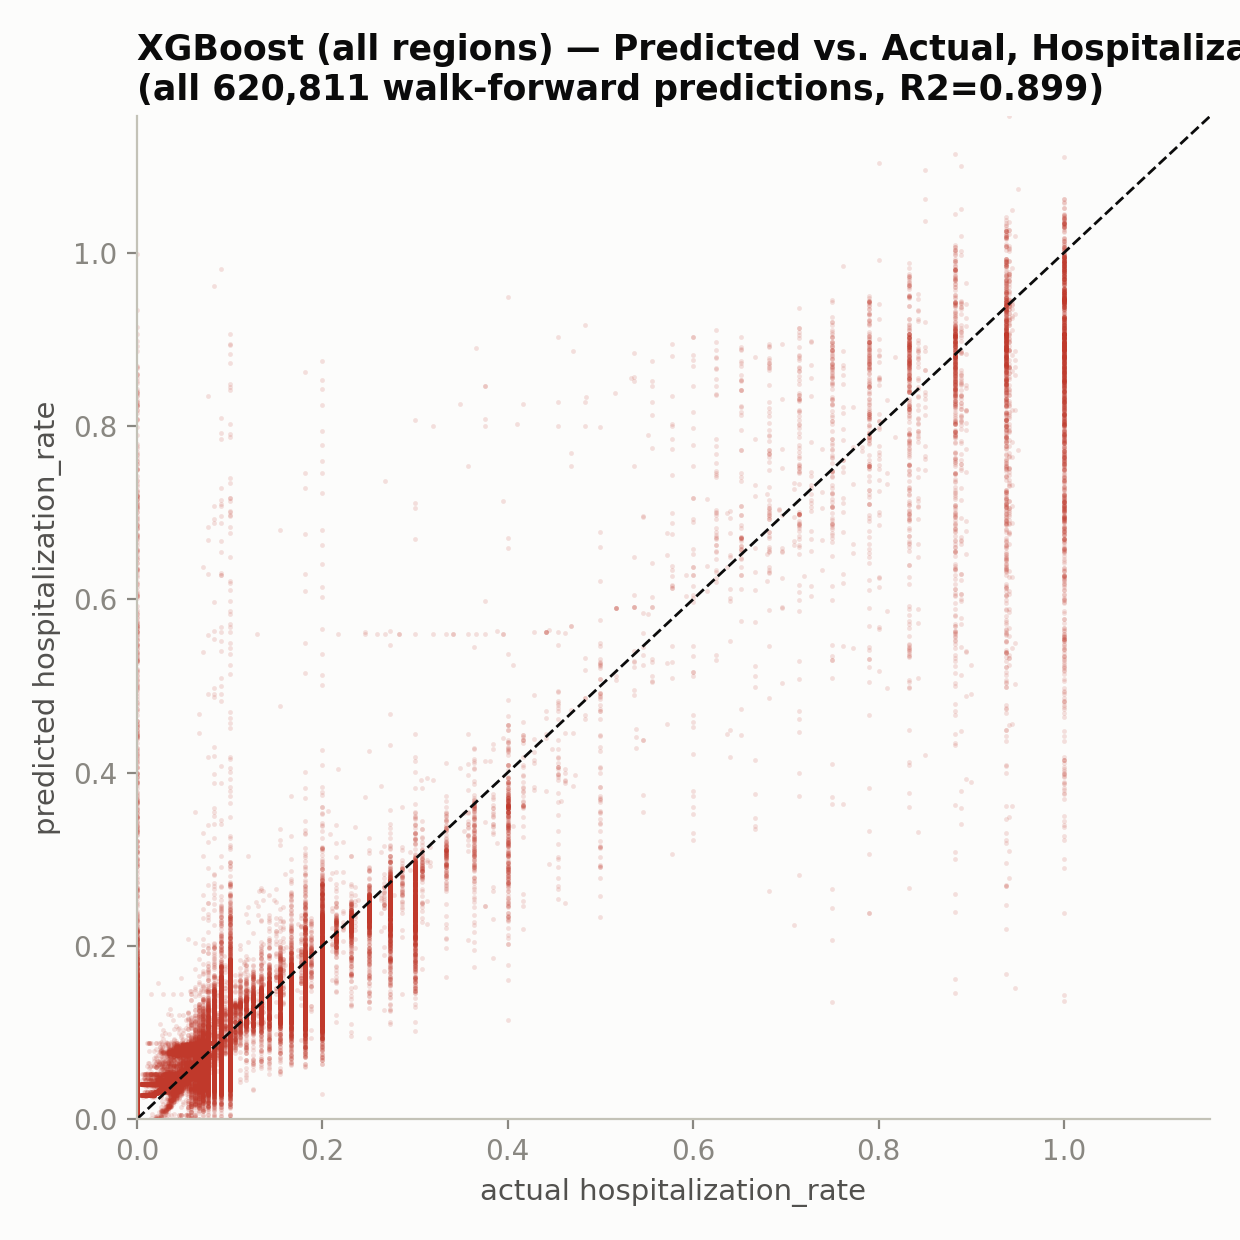

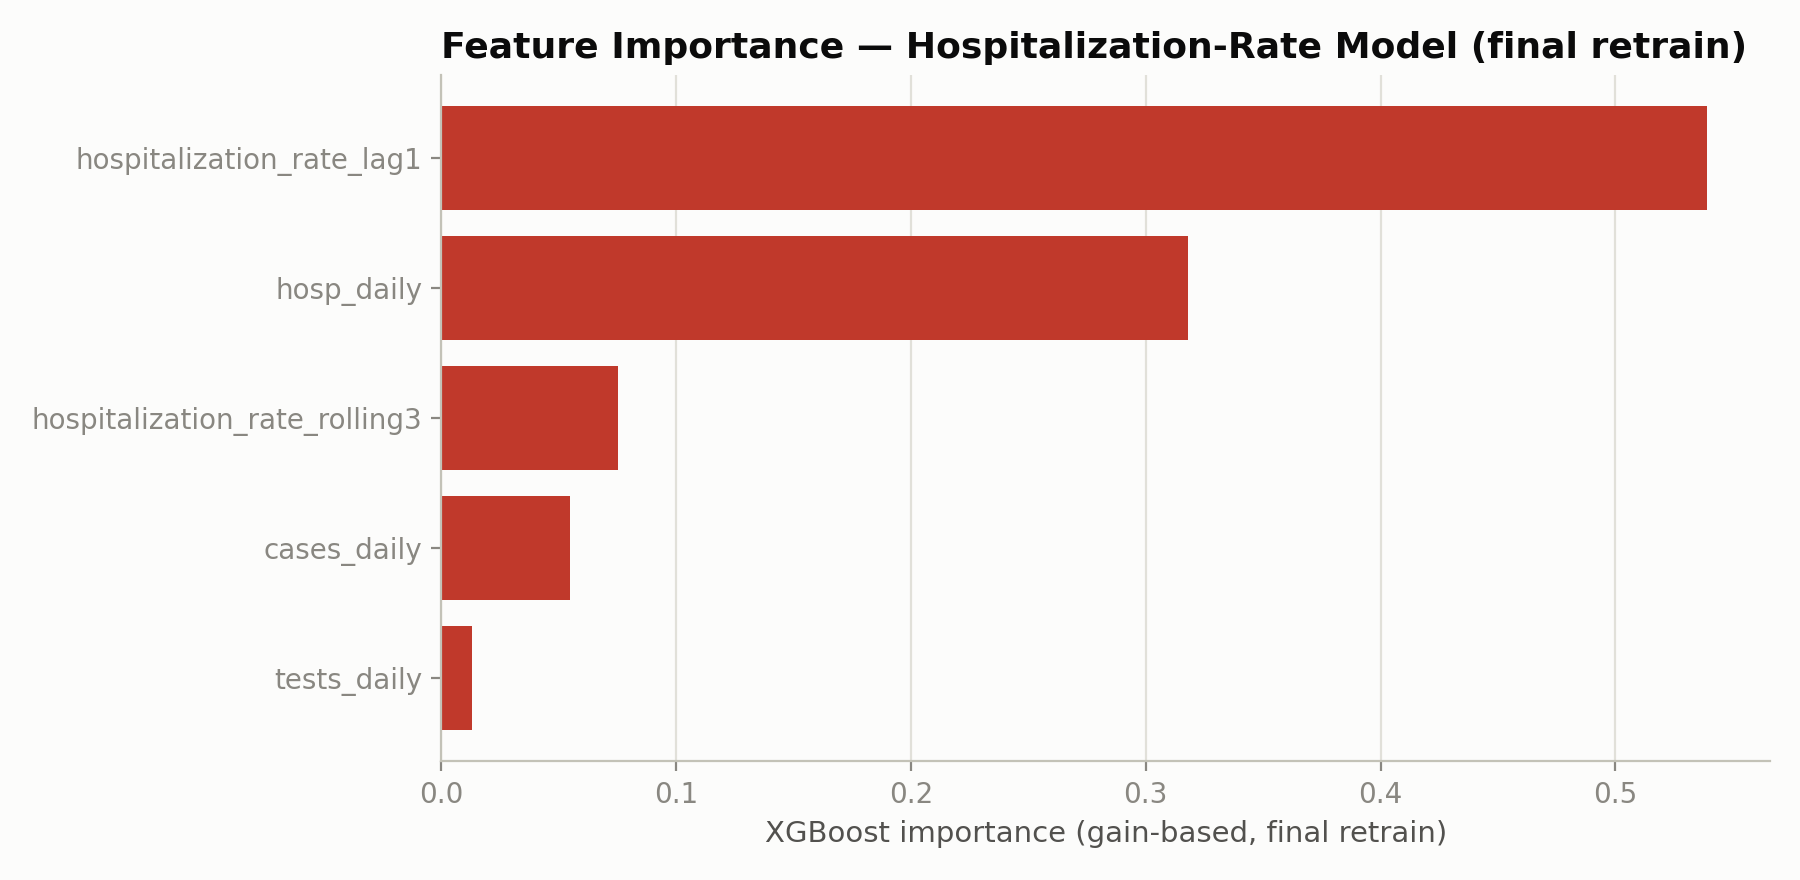

In [6]:
hosp = pd.read_csv("data/processed/walk_forward/xgboost_all_regions_hospitalization_walk_forward/xgboost_all_regions_hosp_wf_overall_results.csv")
print(hosp.to_string(index=False))
for f in ["wf_07_xgb_hospitalization_mae_over_time.png", "wf_08_xgb_hospitalization_scatter.png",
          "wf_09_xgb_hospitalization_feature_importance.png"]:
    display(Image(filename=f"final_submission/figures/05_walk_forward/{f}"))

The method transfers but the target is much noisier: recent hospitalisation history is
still the dominant feature, accuracy is lower and peak-lag more pronounced — hospitalisation
/ mortality forecasting at this geographic resolution stays a stretch target (consistent
with the project's early decision to focus on infection rate).

## Final Analysis

**Initial questions (from the proposal) and how they resolved**

1. *Can we forecast local COVID-19 infection dynamics per statistical area?*
   **Yes.** A shared XGBoost on 1,397 areas reaches walk-forward **R² ≈ 0.95 /
   MAE ≈ 0.013**, comfortably beating the persistence baseline, and generalises across
   the country (per-region R² distribution, nb 04 B.2 / nb 05 §5.2).

2. *Does socio-economic / census structure improve local prediction?*
   **Almost not, for short-horizon forecasting.** Cross-sectionally (nb 03) census
   structure explains only the *average* wave-2 level of a locality (`mean_IR`
   R² ≈ 0.62) and nothing about wave shape or severity; once recent-history features
   are in the model (nb 04–05) the census adds no measurable accuracy, and its
   association with infection burden even flips sign between waves (nb 02 §2.6).

3. *Which variables predict infection trends?*
   **Recent local history.** `infection_rate` rolling-3 + lag-1 carry essentially all
   the signal in both model families; daily hospitalisations contribute ≈ 0.

**New questions raised along the way** — is testing behaviour driving the apparent
geographic heterogeneity (nb 02 §2.3)? does the model's weakness at wave turning
points matter more than its high average R² (nb 05 §5.2)? would a 7-day *multi-step*
horizon or explicit change-point features help at surges?

**Limitations to state with the results**

* Confirmed cases reflect **who got tested**, not true infections (policy / behaviour
  differ by community and over time).
* Census data is **static** — blind to pandemic-era migration, employment, behaviour.
* Fine-resolution local data is **sparse / zero-heavy**; COVID sub-area codes vs 2022
  census `StatArea` codes disagree for a sizeable minority of localities (nb 01 §1.5).
* **Non-stationarity** — variants, vaccination, waning immunity, policy all shift
  between waves; the model is weakest exactly at wave onsets.
* This is a **predictive, not causal** framework — no claim that any census
  characteristic *causes* infection.

**Practical takeaway.** Local infection-rate forecasting is feasible and cheap
(XGBoost, 5 features) and is a reasonable decision-support signal *between* waves;
its value for **surge early-warning** is limited by the turning-point lag, which is
the priority for future work (multi-step horizon, change-point features, mobility data).